In [ ]:
# Notebook of sorted visualizations (stacked bar charts) based on newspaper groups.
# Also includes detailed results for each group.

In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import json
import os

In [ ]:
# read the pkl as a df
df = pd.read_pickle('.../news_embeddings_df_random_selection.pkl')

In [3]:
df.columns

Index(['text', 'date', 'id', 'pwa', 'newspaper', 'pooled',
       'predicted_category', 'year'],
      dtype='object')

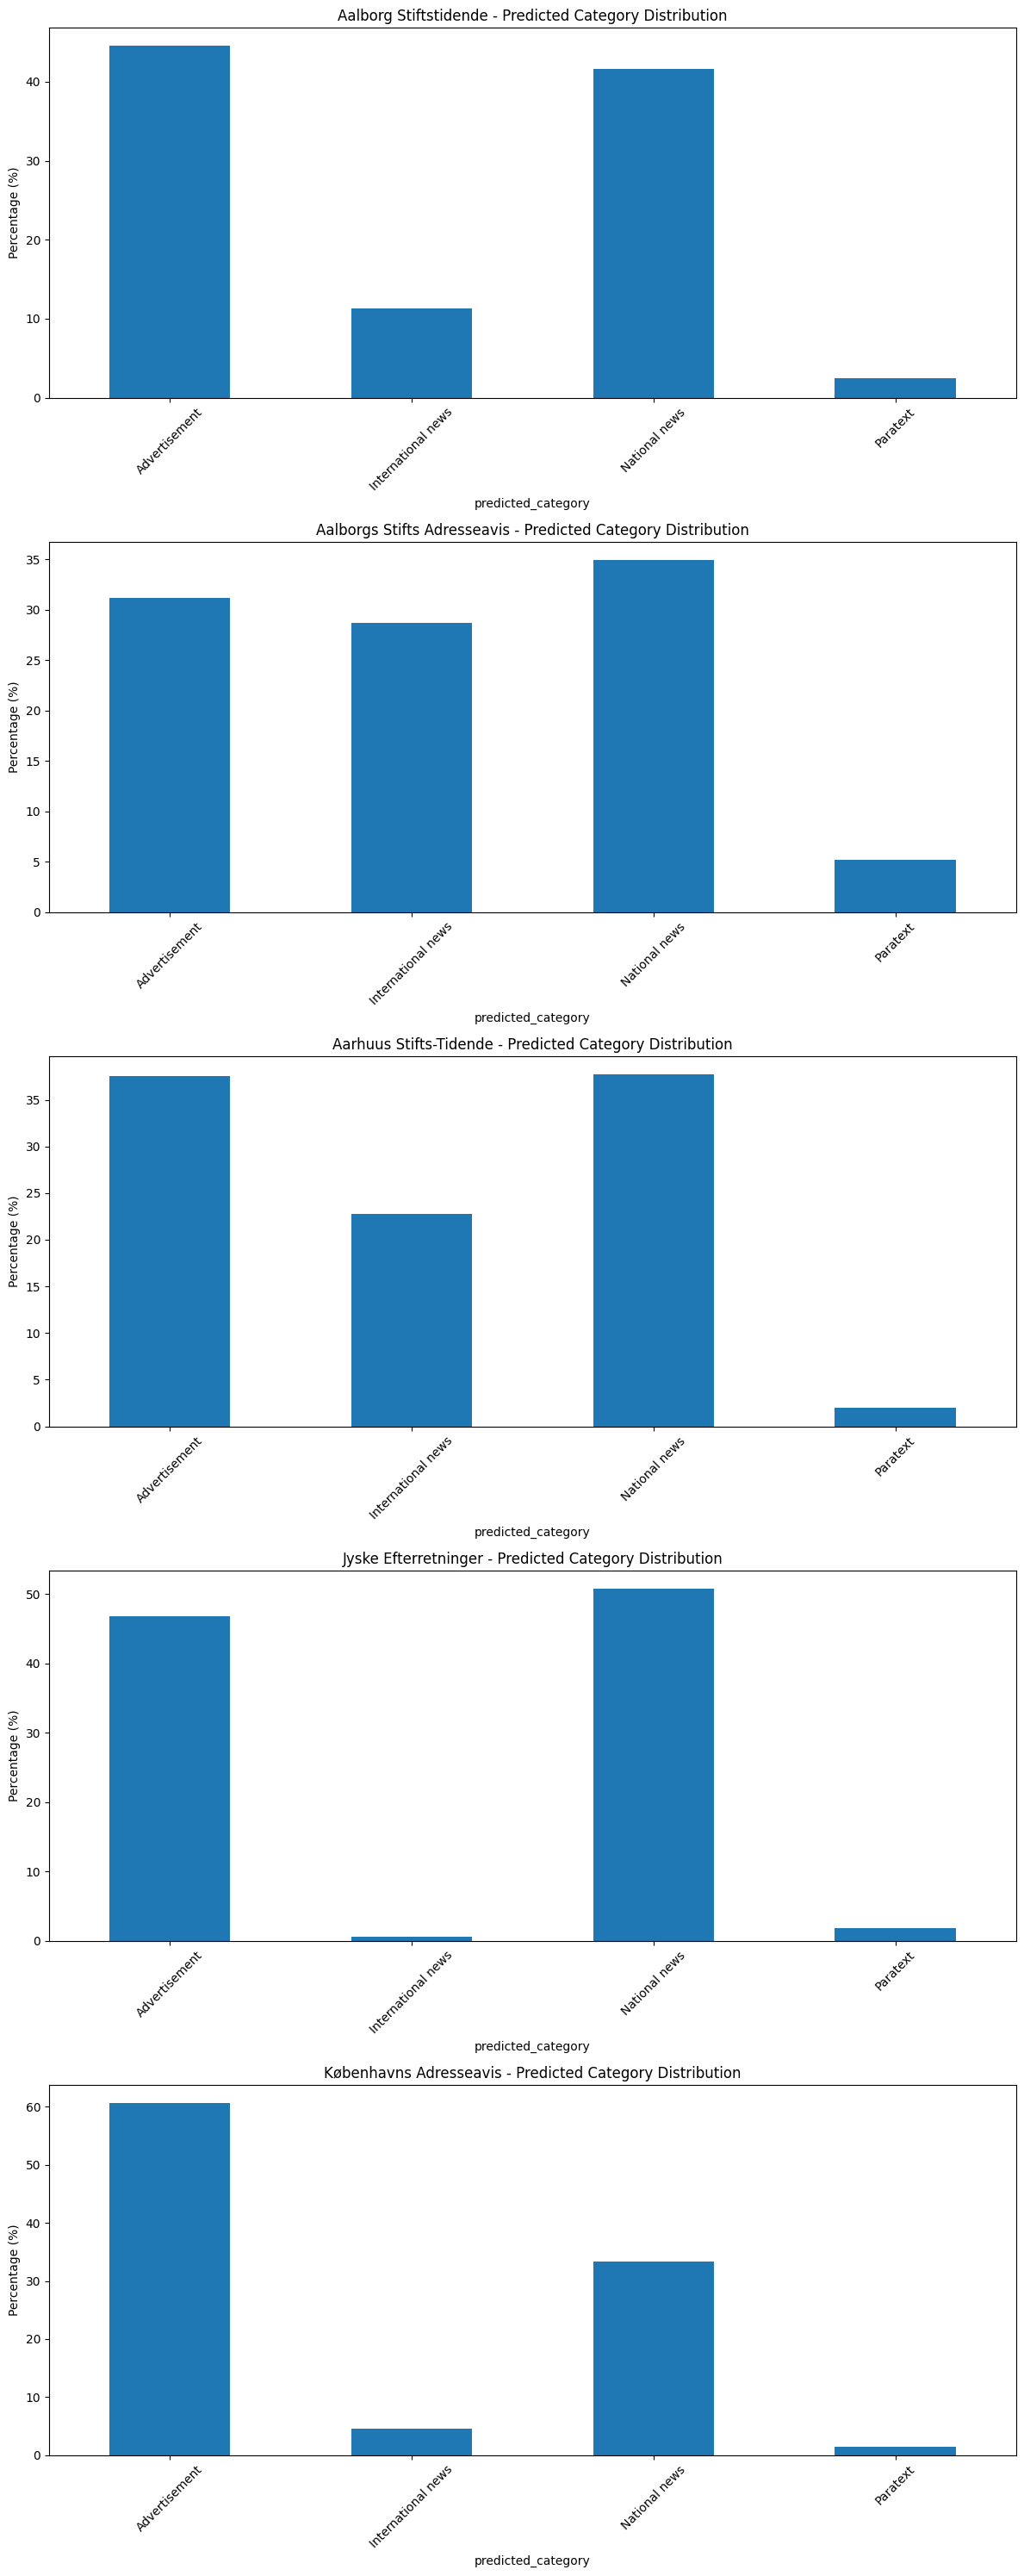

In [ ]:
# Categories visualization

newspaper_category_counts = df.groupby(['newspaper', 'predicted_category']).size().unstack(fill_value=0)
newspaper_category_percentages = newspaper_category_counts.div(newspaper_category_counts.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(len(newspaper_category_percentages), 1, figsize=(12, 6*len(newspaper_category_percentages)))

if len(newspaper_category_percentages) == 1:
    axes = [axes]

for i, (newspaper, percentages) in enumerate(newspaper_category_percentages.iterrows()):
    percentages.plot(kind='bar', ax=axes[i], title=f'{newspaper} - Predicted Category Distribution')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

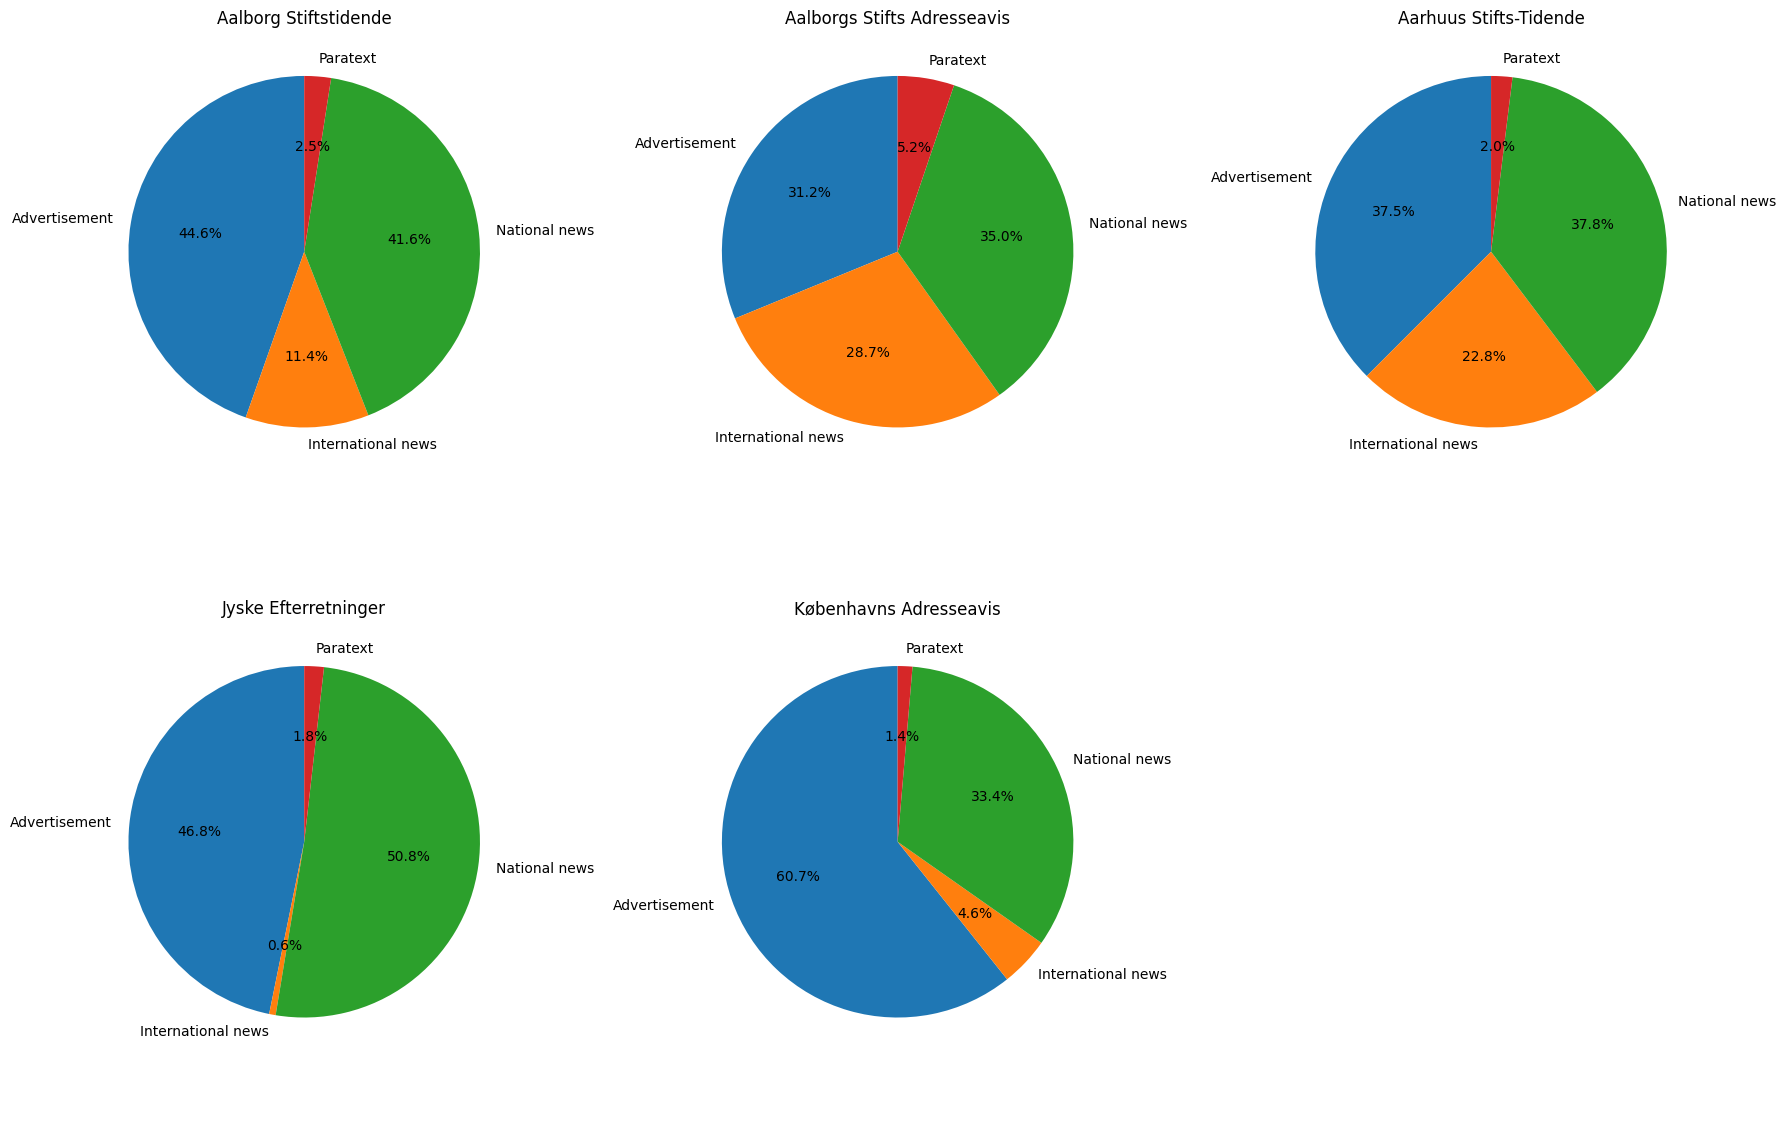

In [ ]:
# Pie charts for each newspaper
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (newspaper, percentages) in enumerate(newspaper_category_percentages.iterrows()):
    axes[i].pie(percentages.values, labels=percentages.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'{newspaper}')

# Hide the extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

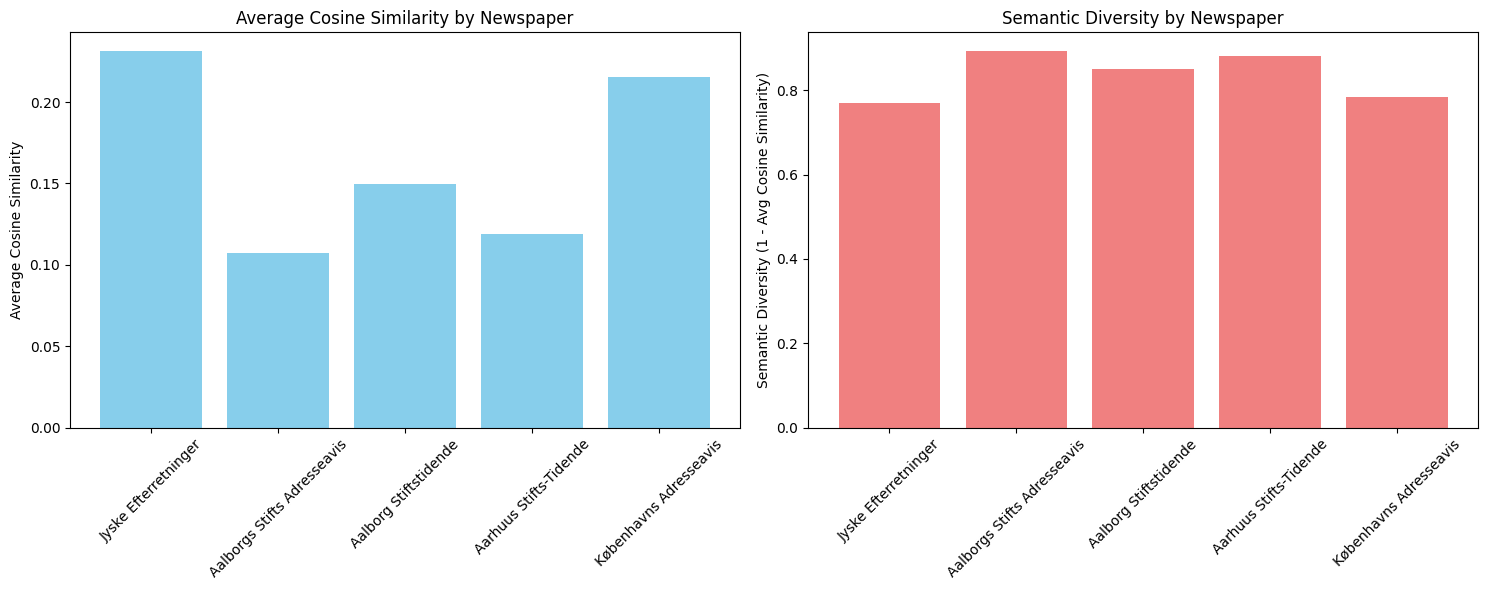

Semantic Diversity Results:
--------------------------------------------------
Jyske Efterretninger:
  Average Cosine Similarity: 0.2313
  Semantic Diversity: 0.7687

Aalborgs Stifts Adresseavis:
  Average Cosine Similarity: 0.1072
  Semantic Diversity: 0.8928

Aalborg Stiftstidende:
  Average Cosine Similarity: 0.1498
  Semantic Diversity: 0.8502

Aarhuus Stifts-Tidende:
  Average Cosine Similarity: 0.1188
  Semantic Diversity: 0.8812

Københavns Adresseavis:
  Average Cosine Similarity: 0.2157
  Semantic Diversity: 0.7843



In [ ]:
# Semantic diversity for each newspaper by computing average cosine similarity
semantic_diversity_results = {}

for newspaper in df['newspaper'].unique():
    # embeddings for this newspaper
    newspaper_data = df[df['newspaper'] == newspaper]
    embeddings = np.array(newspaper_data['pooled'].tolist())
    
    # pairwise cosine similarities
    similarities = cosine_similarity(embeddings)
    
    # upper triangle (excluding diagonal) to avoid counting each pair twice
    upper_triangle = np.triu(similarities, k=1)
    avg_similarity = np.sum(upper_triangle) / (len(embeddings) * (len(embeddings) - 1) / 2)
    
    # Semantic diversity is inverse of similarity
    semantic_diversity = 1 - avg_similarity
    semantic_diversity_results[newspaper] = {
        'avg_cosine_similarity': avg_similarity,
        'semantic_diversity': semantic_diversity
    }

# visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

newspapers = list(semantic_diversity_results.keys())
similarities = [semantic_diversity_results[n]['avg_cosine_similarity'] for n in newspapers]
diversities = [semantic_diversity_results[n]['semantic_diversity'] for n in newspapers]

# Plot average cosine similarities
ax1.bar(newspapers, similarities, color='skyblue')
ax1.set_title('Average Cosine Similarity by Newspaper')
ax1.set_ylabel('Average Cosine Similarity')
ax1.tick_params(axis='x', rotation=45)

# Plot semantic diversities
ax2.bar(newspapers, diversities, color='lightcoral')
ax2.set_title('Semantic Diversity by Newspaper')
ax2.set_ylabel('Semantic Diversity (1 - Avg Cosine Similarity)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# results
print("Semantic Diversity Results:")
print("-" * 50)
for newspaper, results in semantic_diversity_results.items():
    print(f"{newspaper}:")
    print(f"  Average Cosine Similarity: {results['avg_cosine_similarity']:.4f}")
    print(f"  Semantic Diversity: {results['semantic_diversity']:.4f}")
    print()

In [ ]:
news_samples_dir = '.../news_samples'

In [16]:
# Get all JSON files in the directory
json_files = [f for f in os.listdir(news_samples_dir) if f.endswith('.jsonl')]

In [18]:
# Read the three jsonl files
all_data = []

for json_file in json_files:
    file_path = os.path.join(news_samples_dir, json_file)
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line.strip())
            data['source_file'] = json_file  # Add source file info
            all_data.append(data)

print(f"Total records loaded: {len(all_data)}")
print(f"Files processed: {json_files}")

Total records loaded: 300
Files processed: ['opinion-based-papers-mostly-nineteenth-century.jsonl', 'early-newspaper-very-much-in-a-european-style-a-lot-of-international-news.jsonl', 'local-national-papers-as-the-market-matures-more-ads-more-diverse-topics-than-1.jsonl']


In [ ]:
# all_data to DataFrame for easier analysis
all_jsonl_df = pd.DataFrame(all_data)

# percentage of each category in the JSONL data
category_counts = all_jsonl_df['predicted_category'].value_counts()
category_percentages = (category_counts / len(all_jsonl_df)) * 100

print("Category distribution in JSONL files:")
print("-" * 40)
for category, percentage in category_percentages.items():
    print(f"{category}: {percentage:.2f}% ({category_counts[category]} articles)")

print(f"\nTotal articles: {len(all_jsonl_df)}")

# breakdown by source file
print("\nBreakdown by source file:")
print("-" * 40)
file_category_crosstab = pd.crosstab(all_jsonl_df['source_file'], all_jsonl_df['predicted_category'], margins=True)
print(file_category_crosstab)

Category distribution in JSONL files:
----------------------------------------
National news: 61.00% (183 articles)
Advertisement: 23.00% (69 articles)
International news: 11.00% (33 articles)
Paratext: 5.00% (15 articles)

Total articles: 300

Breakdown by source file:
----------------------------------------
predicted_category                                  Advertisement  \
source_file                                                         
early-newspaper-very-much-in-a-european-style-a...              0   
local-national-papers-as-the-market-matures-mor...             43   
opinion-based-papers-mostly-nineteenth-century....             26   
All                                                            69   

predicted_category                                  International news  \
source_file                                                              
early-newspaper-very-much-in-a-european-style-a...                  33   
local-national-papers-as-the-market-matures-mor... 

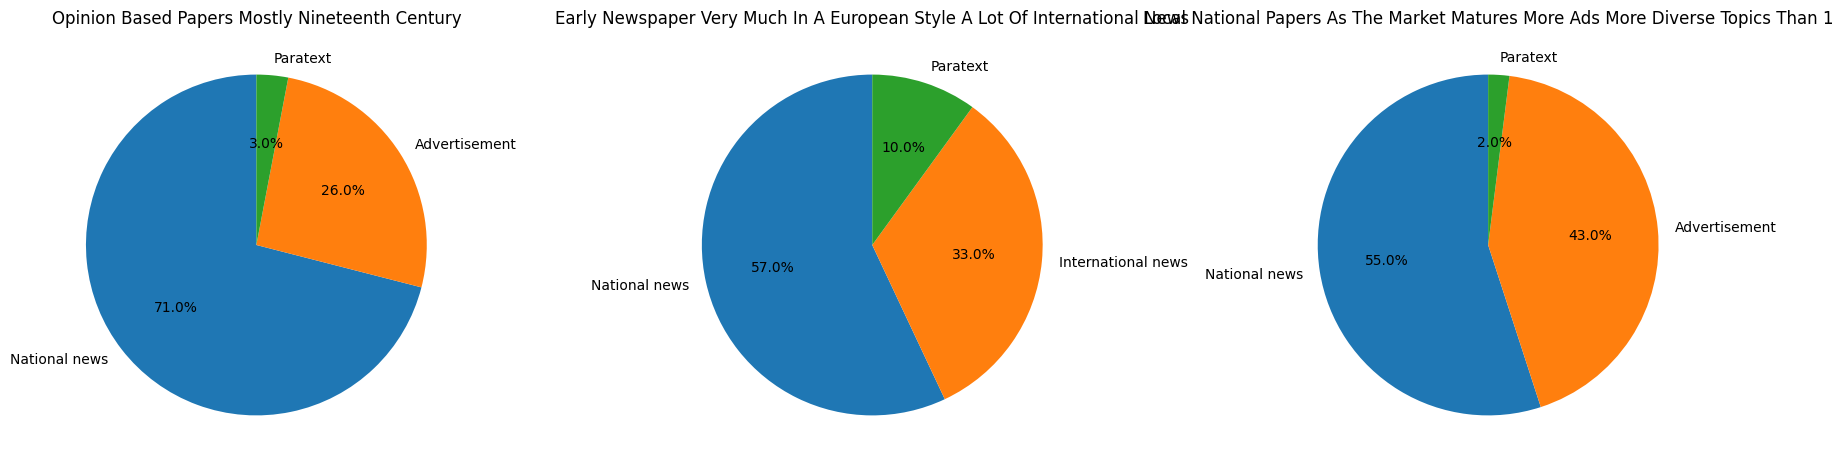

In [ ]:
# pie charts for each JSON file
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, json_file in enumerate(json_files):
    # data for this specific file
    file_data = all_jsonl_df[all_jsonl_df['source_file'] == json_file]
    category_counts = file_data['predicted_category'].value_counts()
    
    # pie chart
    axes[i].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(json_file.replace('.jsonl', '').replace('-', ' ').title())

plt.tight_layout()
plt.show()

In [3]:
import glob
glob.glob('/Users/au701203/Downloads/sample_2000_each/*')

['/Users/au701203/Downloads/sample_2000_each/state.json',
 '/Users/au701203/Downloads/sample_2000_each/dataset_info.json',
 '/Users/au701203/Downloads/sample_2000_each/data-00000-of-00001.arrow']

In [ ]:
from datasets import load_from_disk
ds = load_from_disk("/Users/au701203/Downloads/sample_2000_each")
df = ds.to_pandas()

In [9]:
df.columns

Index(['text', 'date', 'id', 'pwa', 'newspaper', 'pooled',
       'predicted_category'],
      dtype='object')

In [10]:
len(df)

54362

In [ ]:
# percentage of predicted categories for each newspaper
newspaper_category_crosstab = pd.crosstab(df['newspaper'], df['predicted_category'], normalize='index') * 100

print("Percentage of predicted categories by newspaper:")
print("=" * 60)
print(newspaper_category_crosstab.round(2))

# Also show counts for reference
print("\n\nActual counts by newspaper:")
print("=" * 60)
counts_crosstab = pd.crosstab(df['newspaper'], df['predicted_category'], margins=True)
print(counts_crosstab)

Percentage of predicted categories by newspaper:
predicted_category                             Advertisement  \
newspaper                                                      
Aalborg Stiftstidende                                  38.05   
Aalborgs Stifts Adresseavis                            35.60   
Aarhuus Stifts-Tidende                                 43.45   
Adresseavis for Børn                                    4.28   
Almuevennen                                            21.35   
Berlingske Tidende                                     51.90   
Corsaren                                                5.65   
Danske Mercurius                                        0.65   
Den Nord-Cimbriske Tilskuer                            17.60   
Den Vest-Sjællandske Avis                              36.25   
Efterretninger fra Adresse-Contoiret i Bergen          78.80   
Extraordinaire Maanedlige Relationer                    5.30   
Extraordinaire Relationer                              

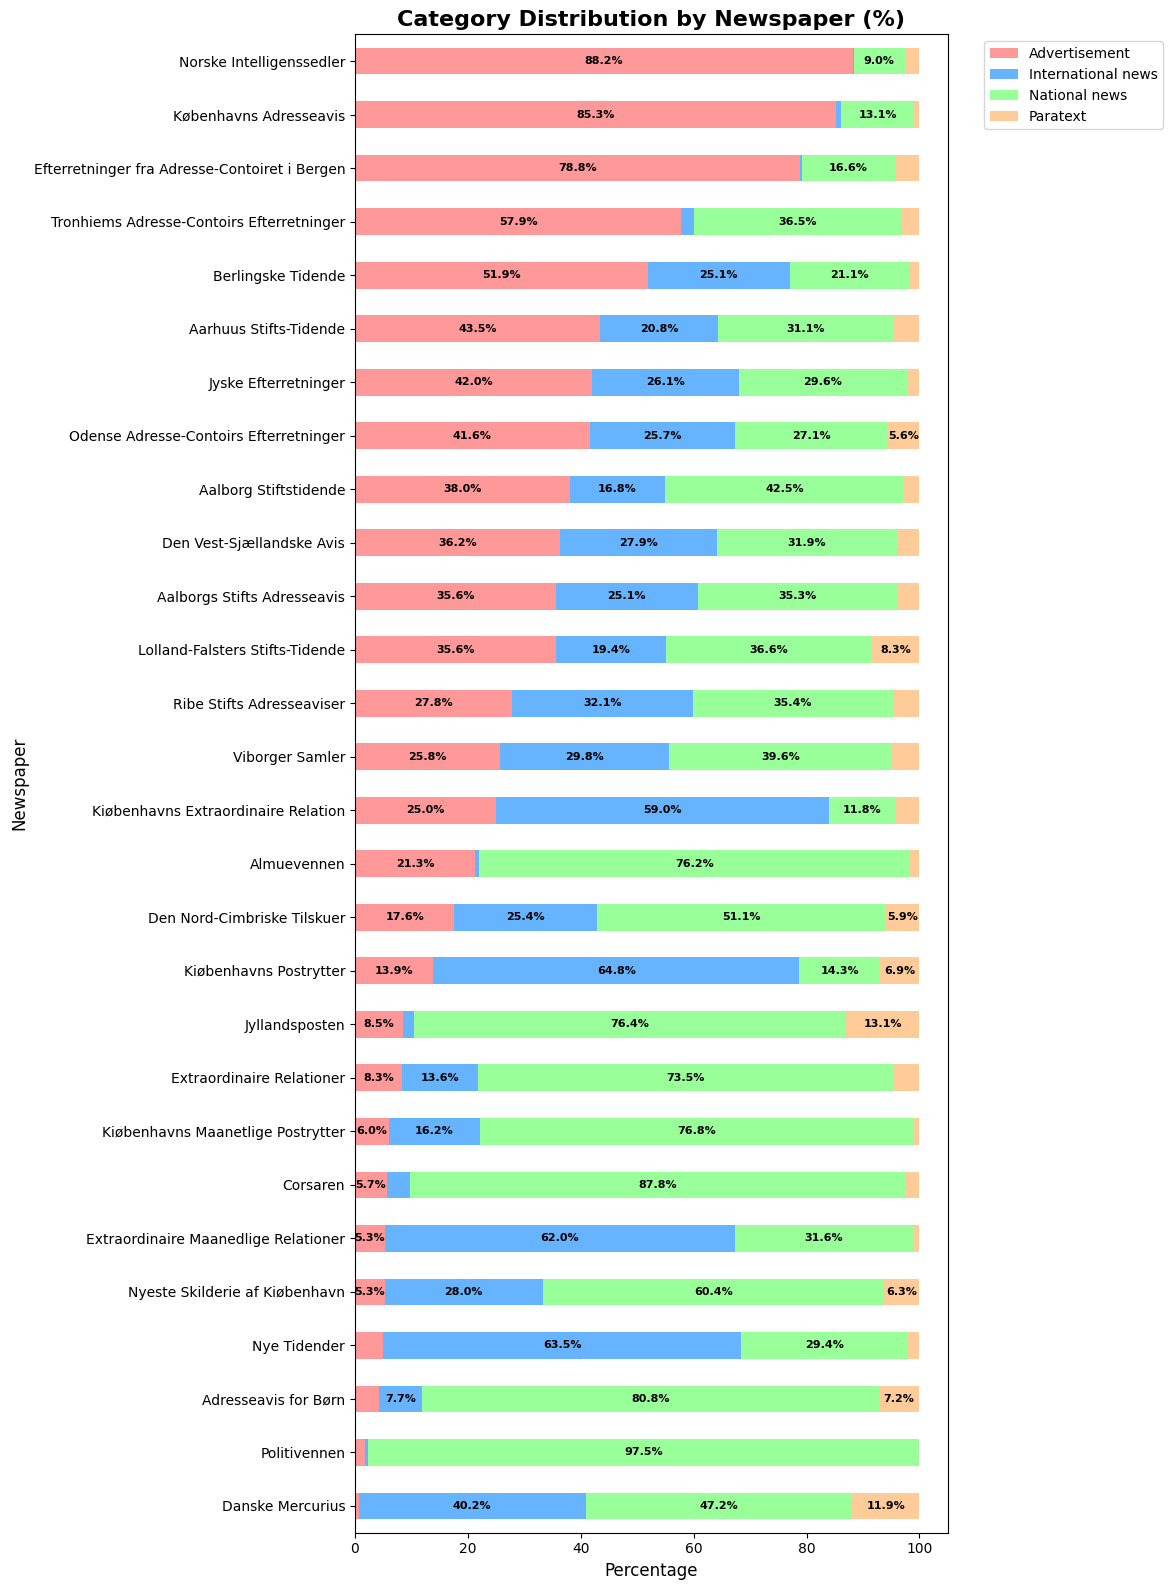

In [16]:
# Create a horizontal bar chart showing category percentages for each newspaper
fig, ax = plt.subplots(figsize=(12, 16))

# Sort newspapers by total Advertisement percentage for better visualization
sorted_newspapers = newspaper_category_crosstab.sort_values('Advertisement', ascending=True)

# Create horizontal stacked bar chart
sorted_newspapers.plot(kind='barh', stacked=True, ax=ax, 
                      color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])

ax.set_title('Category Distribution by Newspaper (%)', fontsize=16, fontweight='bold')
ax.set_xlabel('Percentage', fontsize=12)
ax.set_ylabel('Newspaper', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels on bars
for i, newspaper in enumerate(sorted_newspapers.index):
    cumulative = 0
    for category in sorted_newspapers.columns:
        percentage = sorted_newspapers.loc[newspaper, category]
        if percentage > 5:  # Only show labels for percentages > 5%
            ax.text(cumulative + percentage/2, i, f'{percentage:.1f}%', 
                   ha='center', va='center', fontweight='bold', fontsize=8)
        cumulative += percentage

plt.tight_layout()
plt.show()

In [22]:
newspaper_groups = {
    "Early newspaper": [
        "Nye Tidender",
        "Danske Mercurius",
        "Extraordinaire Maanedlige Relationer",
        "Extraordinaire Relationer",
        "Kiøbenhavns Extraordinaire Relation",
        "Kiøbenhavns Maanetlige Postrytter",
        "Kiøbenhavns Postrytter"
    ],

    "Local/National": [
        "Aalborg Stiftstidende",
        "Aalborgs Stifts Adresseavis",
        "Aarhuus Stifts-Tidende",
        "Odense Adresse-Contoirs Efterretninger",
        "Ribe Stifts Adresseaviser",
        "Tronhiems Adresse-Contoirs Efterretninger",
        "Viborger Samler",
        "Berlingske Tidende",
        "Den Nord-Cimbriske Tilskuer",
        "Den Vest-Sjællandske Avis",
        "Efterretninger fra Adresse-Contoiret i Bergen",
        "Jyske Efterretninger",
        "Københavns Adresseavis",
        "Lolland-Falsters Stifts-Tidende",
        "Norske Intelligenssedler"
    ],

    "Opinion-based": [
        "Corsaren",
        "Almuevennen",
        "Politivennen",
        "Jyllandsposten",
        "Nyeste Skilderie af Kiøbenhavn"
    ]
}


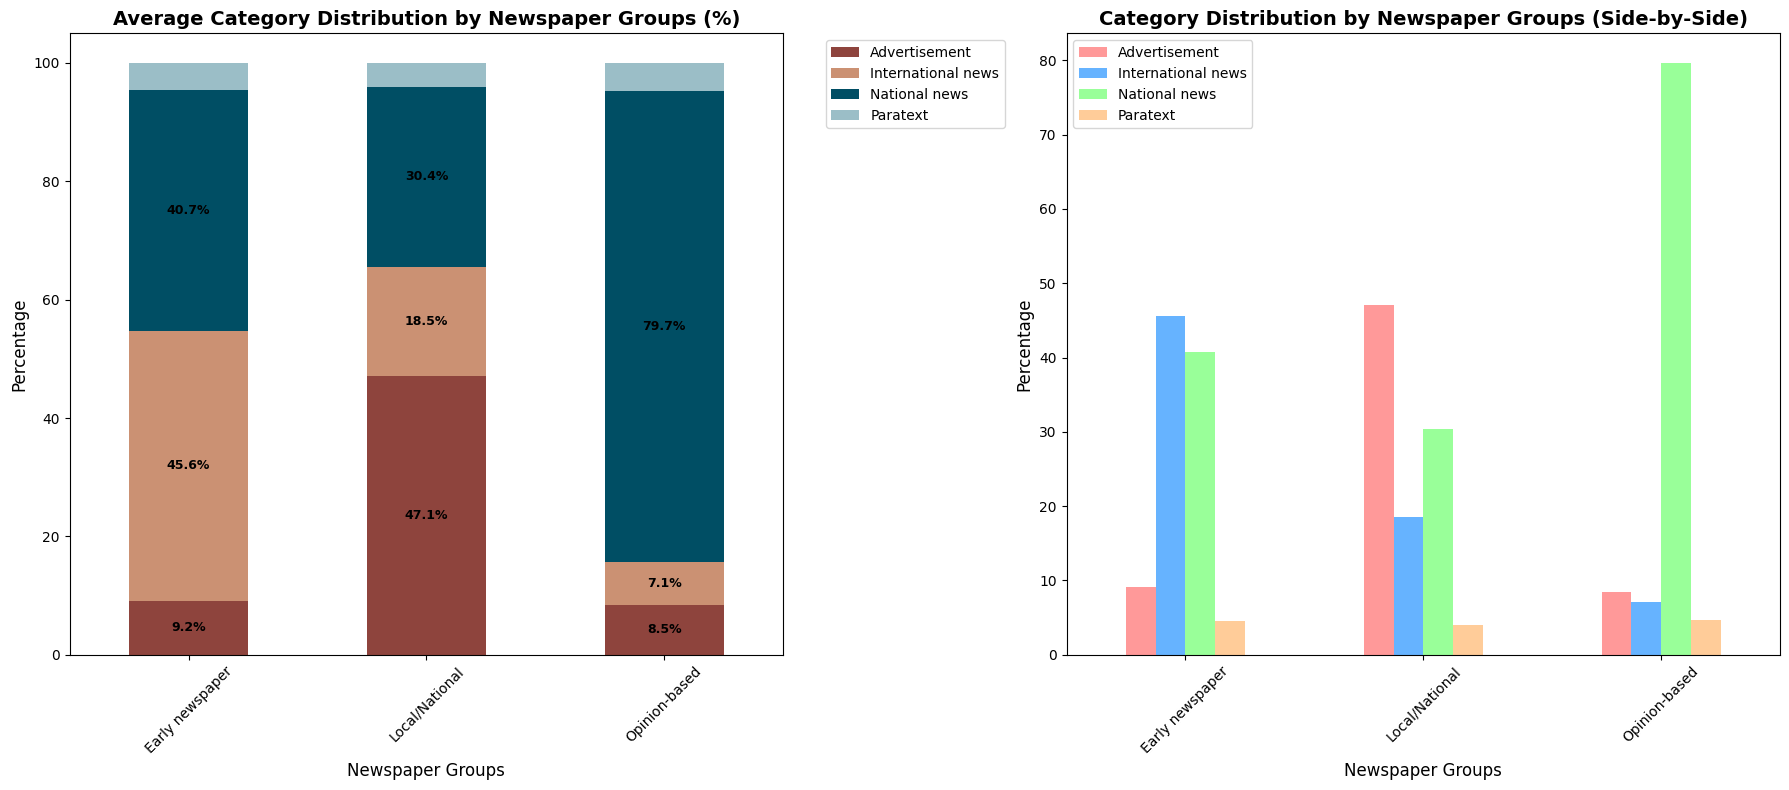

Average Category Distribution by Newspaper Groups:

Early newspaper:
Newspapers included: ['Nye Tidender', 'Danske Mercurius', 'Extraordinaire Maanedlige Relationer', 'Extraordinaire Relationer', 'Kiøbenhavns Extraordinaire Relation', 'Kiøbenhavns Maanetlige Postrytter', 'Kiøbenhavns Postrytter']
predicted_category
Advertisement          9.16
International news    45.60
National news         40.69
Paratext               4.56
Name: Early newspaper, dtype: float64

Local/National:
Newspapers included: ['Aalborg Stiftstidende', 'Aalborgs Stifts Adresseavis', 'Aarhuus Stifts-Tidende', 'Odense Adresse-Contoirs Efterretninger', 'Ribe Stifts Adresseaviser', 'Tronhiems Adresse-Contoirs Efterretninger', 'Viborger Samler', 'Berlingske Tidende', 'Den Nord-Cimbriske Tilskuer', 'Den Vest-Sjællandske Avis', 'Efterretninger fra Adresse-Contoiret i Bergen', 'Jyske Efterretninger', 'Københavns Adresseavis', 'Lolland-Falsters Stifts-Tidende', 'Norske Intelligenssedler']
predicted_category
Advertisement 

In [ ]:
# grouped dataframe based on newspaper_groups
grouped_data = {}

for group_name, newspapers in newspaper_groups.items():
    # Filter newspapers that exist in our crosstab
    existing_newspapers = [n for n in newspapers if n in newspaper_category_crosstab.index]
    
    if existing_newspapers:
        # Calculate average percentages for this group
        group_data = newspaper_category_crosstab.loc[existing_newspapers].mean()
        grouped_data[group_name] = group_data

# to DataFrame
grouped_df = pd.DataFrame(grouped_data).T

# visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Stacked bar chart
grouped_df.plot(kind='bar', stacked=True, ax=ax1, 
                color= ['#8E443D', '#CB9173', '#004E64', '#9BBEC7'])
ax1.set_title('Average Category Distribution by Newspaper Groups (%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Percentage', fontsize=12)
ax1.set_xlabel('Newspaper Groups', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# percentage labels on bars
for i, group in enumerate(grouped_df.index):
    cumulative = 0
    for category in grouped_df.columns:
        percentage = grouped_df.loc[group, category]
        if percentage > 5:  # Only show labels for percentages > 5%
            ax1.text(i, cumulative + percentage/2, f'{percentage:.1f}%', 
                    ha='center', va='center', fontweight='bold', fontsize=9)
        cumulative += percentage

# Grouped bar chart for comparison
grouped_df.plot(kind='bar', ax=ax2, 
                color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
ax2.set_title('Category Distribution by Newspaper Groups (Side-by-Side)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Percentage', fontsize=12)
ax2.set_xlabel('Newspaper Groups', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

# detailed results
print("Average Category Distribution by Newspaper Groups:")
print("=" * 60)
for group_name, newspapers in newspaper_groups.items():
    existing_newspapers = [n for n in newspapers if n in newspaper_category_crosstab.index]
    print(f"\n{group_name}:")
    print(f"Newspapers included: {existing_newspapers}")
    if existing_newspapers:
        print(grouped_df.loc[group_name].round(2))

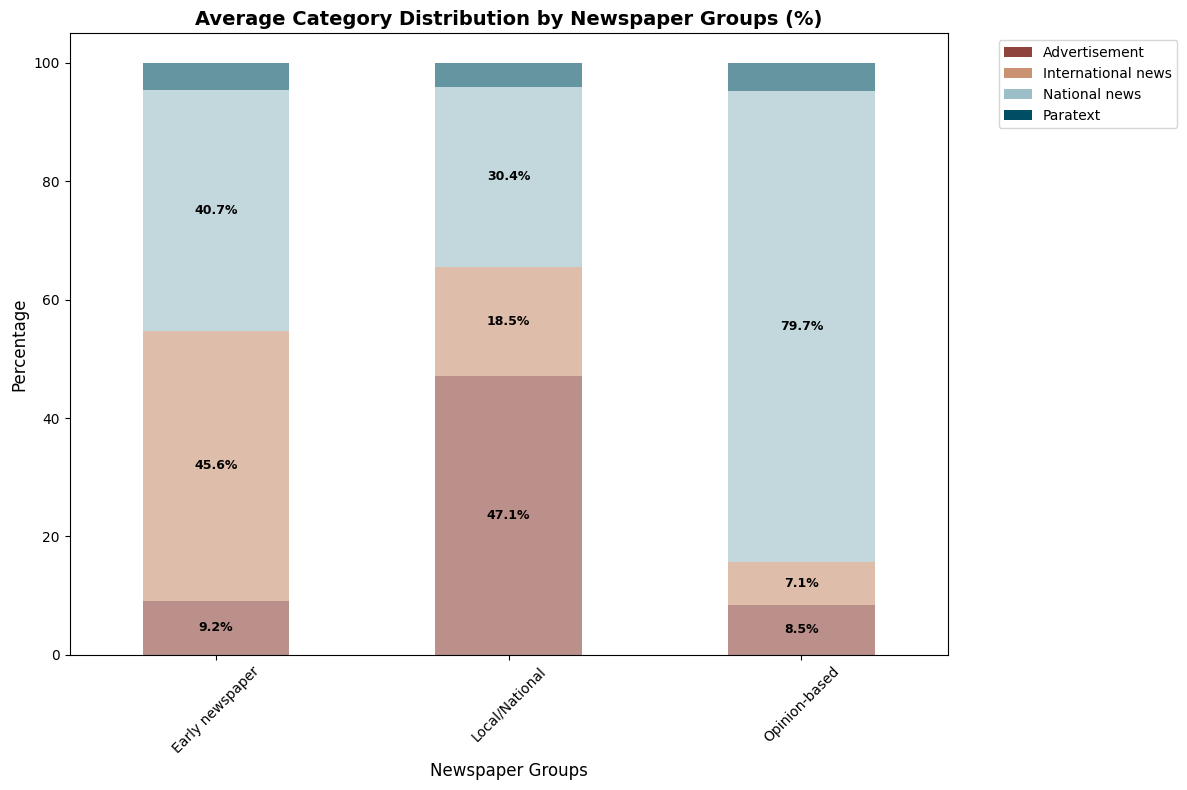

In [ ]:
# a simple stacked bar chart showing category percentages for each newspaper group
fig, ax = plt.subplots(figsize=(12, 8))

# stacked bar chart
grouped_df.plot(kind='bar', stacked=True, ax=ax, 
                color= ['#8E443D', '#CB9173', '#9BBEC7', '#004E64',])

ax.set_title('Average Category Distribution by Newspaper Groups (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage', fontsize=12)
ax.set_xlabel('Newspaper Groups', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# percentage labels on bars
for i, group in enumerate(grouped_df.index):
    cumulative = 0
    for category in grouped_df.columns:
        percentage = grouped_df.loc[group, category]
        if percentage > 5:  # Only show labels for percentages > 5%
            ax.text(i, cumulative + percentage/2, f'{percentage:.1f}%', 
                   ha='center', va='center', fontweight='bold', fontsize=9)
        cumulative += percentage


# increase transparency
for patch in ax.patches:
    patch.set_alpha(0.6)


plt.tight_layout()
plt.show()

In [48]:
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull
import re
from plotly.subplots import make_subplots

# Create an enhanced version with more visual features
import plotly.express as px
import plotly.graph_objects as go

# Enhanced version with density contours and interactive features
sample_size = 5000
df_sample = df.sample(n=min(sample_size, len(df)), random_state=42).copy()

def get_newspaper_group(newspaper):
    for group_name, newspapers in newspaper_groups.items():
        if newspaper in newspapers:
            return group_name
    return None

df_sample['group'] = df_sample['newspaper'].apply(get_newspaper_group)
df_sample = df_sample[df_sample['group'].notna()].reset_index(drop=True)

embeddings = np.array(df_sample['pooled'].tolist())

# t-SNE with better parameters
n = len(df_sample)
perplexity = min(30, max(5, (n - 1)//3))

print(f"Creating enhanced semantic map with {n} articles...")
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexity,
    max_iter=1500,
    init='pca',
    learning_rate='auto'
)
emb2d = tsne.fit_transform(embeddings)
df_sample['tsne_x'] = emb2d[:, 0]
df_sample['tsne_y'] = emb2d[:, 1]

# Enhanced color palette with gradients
enhanced_colors = {
    'Early newspaper': '#FF6B35',
    'Local/National': '#004E89', 
    'Opinion-based': '#9A031E'
}

# Create base figure with subplots for density
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Semantic Clustering", "Content Density Heatmap"),
    column_widths=[0.7, 0.3],
    specs=[[{"secondary_y": False}, {"secondary_y": False}]]
)

# Main scatter plot with enhanced styling
for group in df_sample['group'].unique():
    group_data = df_sample[df_sample['group'] == group]
    
    # Add main scatter
    fig.add_trace(
        go.Scatter(
            x=group_data['tsne_x'],
            y=group_data['tsne_y'],
            mode='markers',
            marker=dict(
                color=enhanced_colors[group],
                symbol=group_data['predicted_category'].map({
                    'Advertisement': 'diamond',
                    'International news': 'circle',
                    'National news': 'square',
                    'Paratext': 'x'
                }),
                size=8,
                line=dict(width=1, color='rgba(255,255,255,0.6)'),
                opacity=0.8
            ),
            name=group,
            text=group_data['newspaper'] + '<br>' + group_data['date'] + '<br>' + group_data['predicted_category'],
            hovertemplate='<b>%{text}</b><br>Position: (%{x:.1f}, %{y:.1f})<extra></extra>',
            showlegend=True
        ),
        row=1, col=1
    )
    
    # Add group boundaries with glow effect
    if len(group_data) >= 6:
        pts = group_data[['tsne_x', 'tsne_y']].values
        try:
            hull = ConvexHull(pts)
            hull_pts = pts[hull.vertices]
            x_hull = np.append(hull_pts[:, 0], hull_pts[0, 0])
            y_hull = np.append(hull_pts[:, 1], hull_pts[0, 1])
            
            # Glowing boundary effect
            for width, opacity in [(8, 0.1), (4, 0.2), (2, 0.4)]:
                fig.add_trace(
                    go.Scatter(
                        x=x_hull, y=y_hull,
                        mode='lines',
                        line=dict(color=enhanced_colors[group], width=width),
                        opacity=opacity,
                        hoverinfo='skip',
                        showlegend=False
                    ),
                    row=1, col=1
                )
        except:
            pass

# Add density heatmap
fig.add_trace(
    go.Histogram2d(
        x=df_sample['tsne_x'],
        y=df_sample['tsne_y'],
        colorscale='Viridis',
        showscale=True,
        nbinsx=20,
        nbinsy=20,
        name='Density'
    ),
    row=1, col=2
)

# Enhanced layout with dark theme
fig.update_layout(
    title=dict(
        text='<b>Semantic Archaeology of Historical Danish Newspapers</b><br><sup>Neural embedding visualization revealing content patterns across centuries</sup>',
        x=0.5,
        font=dict(size=18, color='white')
    ),
    plot_bgcolor='rgba(17,17,17,1)',
    paper_bgcolor='rgba(17,17,17,1)',
    font=dict(color='white'),
    width=1400,
    height=800,
    legend=dict(
        bgcolor='rgba(0,0,0,0.5)',
        bordercolor='rgba(255,255,255,0.2)',
        borderwidth=1
    )
)

# Style the axes
fig.update_xaxes(
    title='Semantic Drift →',
    showgrid=True,
    gridcolor='rgba(255,255,255,0.1)',
    zeroline=False,
    row=1, col=1
)
fig.update_yaxes(
    title='↑ Narrative Latitude',
    showgrid=True,
    gridcolor='rgba(255,255,255,0.1)',
    zeroline=False,
    row=1, col=1
)

fig.update_xaxes(title='Semantic Drift', row=1, col=2)
fig.update_yaxes(title='Narrative Latitude', row=1, col=2)

# Add animated transitions and show
fig.show(renderer="browser")

# Print some cool statistics
print("\n🔥 SEMANTIC ARCHAEOLOGY RESULTS 🔥")
print("=" * 50)
for group in df_sample['group'].unique():
    group_data = df_sample[df_sample['group'] == group]
    spread_x = group_data['tsne_x'].std()
    spread_y = group_data['tsne_y'].std()
    print(f"{group}:")
    print(f"  📊 Articles: {len(group_data)}")
    print(f"  🎯 Semantic spread: {spread_x:.2f} × {spread_y:.2f}")
    print(f"  📰 Top newspaper: {group_data['newspaper'].value_counts().index[0]}")
    print()

Creating enhanced semantic map with 4874 articles...

🔥 SEMANTIC ARCHAEOLOGY RESULTS 🔥
Local/National:
  📊 Articles: 2703
  🎯 Semantic spread: 37.43 × 33.06
  📰 Top newspaper: Den Nord-Cimbriske Tilskuer

Opinion-based:
  📊 Articles: 935
  🎯 Semantic spread: 19.59 × 21.67
  📰 Top newspaper: Nyeste Skilderie af Kiøbenhavn

Early newspaper:
  📊 Articles: 1236
  🎯 Semantic spread: 32.39 × 30.17
  📰 Top newspaper: Kiøbenhavns Postrytter



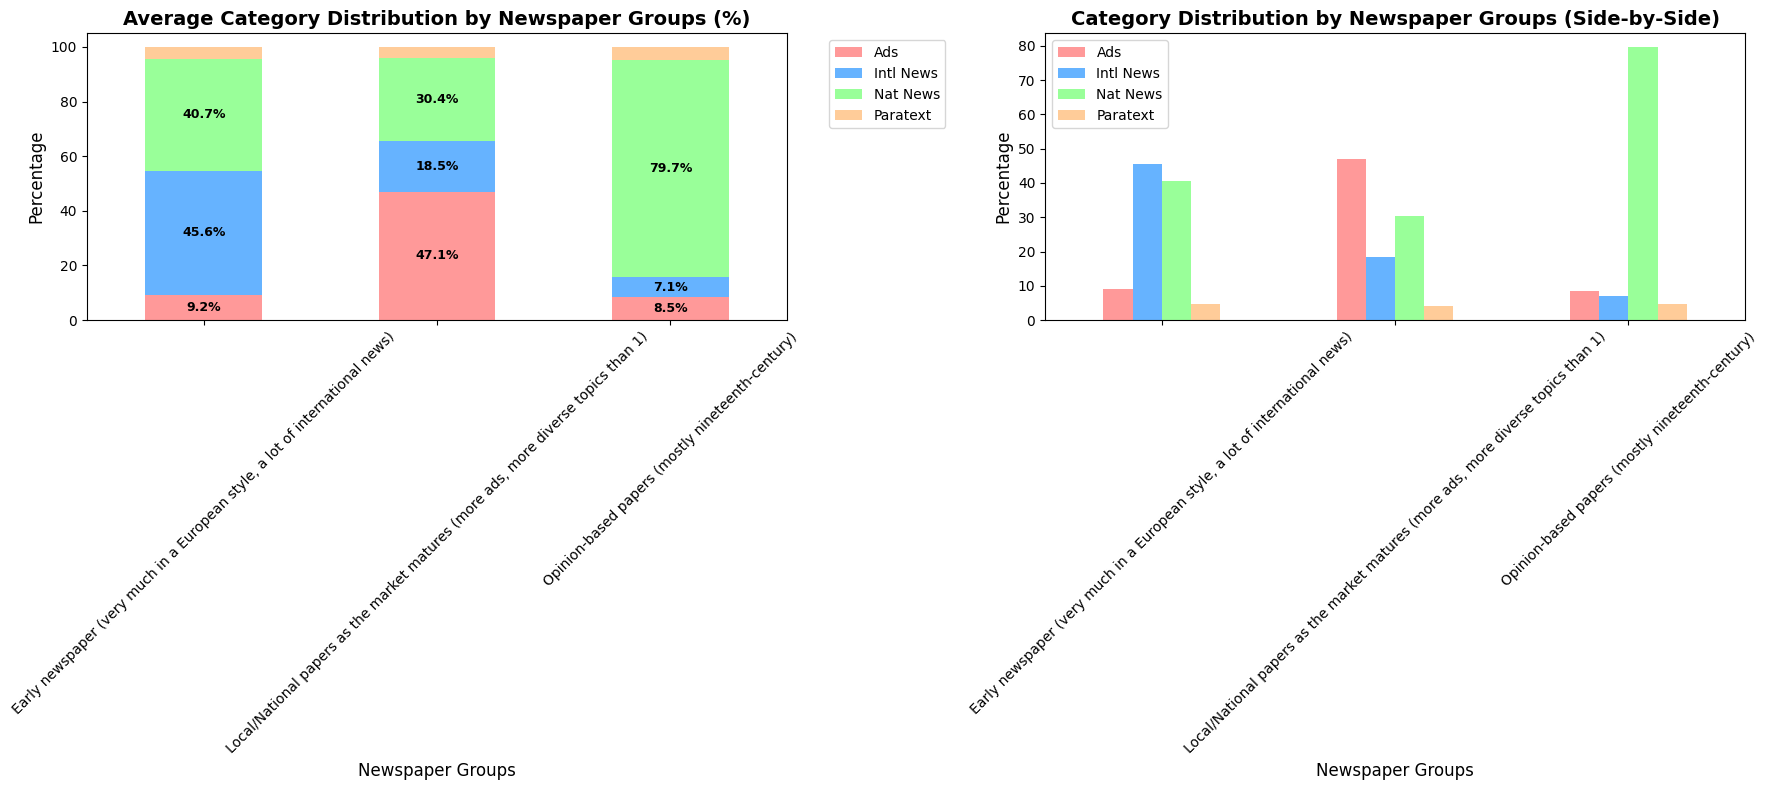

Average Category Distribution by Newspaper Groups (with shorter names):
predicted_category                                    Ads  Intl News  \
Early newspaper (very much in a European style,...   9.16      45.60   
Local/National papers as the market matures (mo...  47.05      18.52   
Opinion-based papers (mostly nineteenth-century)     8.49       7.12   

predicted_category                                  Nat News  Paratext  
Early newspaper (very much in a European style,...     40.69      4.56  
Local/National papers as the market matures (mo...     30.44      3.99  
Opinion-based papers (mostly nineteenth-century)       79.65      4.74  


In [21]:
# Create shorter names for the categories
category_mapping = {
    'Advertisement': 'Ads',
    'International news': 'Intl News',
    'National news': 'Nat News',
    'Paratext': 'Paratext'
}

# Rename columns in grouped_df
grouped_df_short = grouped_df.rename(columns=category_mapping)

# Create visualization with shorter names and better label alignment
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Stacked bar chart
grouped_df_short.plot(kind='bar', stacked=True, ax=ax1, 
                     color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
ax1.set_title('Average Category Distribution by Newspaper Groups (%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Percentage', fontsize=12)
ax1.set_xlabel('Newspaper Groups', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels on bars with proper alignment
for i, group in enumerate(grouped_df_short.index):
    cumulative = 0
    for category in grouped_df_short.columns:
        percentage = grouped_df_short.loc[group, category]
        if percentage > 5:  # Only show labels for percentages > 5%
            ax1.text(i, cumulative + percentage/2, f'{percentage:.1f}%', 
                    ha='center', va='center', fontweight='bold', fontsize=9)
        cumulative += percentage

# Grouped bar chart for comparison
grouped_df_short.plot(kind='bar', ax=ax2, 
                     color=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'])
ax2.set_title('Category Distribution by Newspaper Groups (Side-by-Side)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Percentage', fontsize=12)
ax2.set_xlabel('Newspaper Groups', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

# Print results with shorter names
print("Average Category Distribution by Newspaper Groups (with shorter names):")
print("=" * 70)
print(grouped_df_short.round(2))

In [34]:
# --- Imports ---
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy.spatial import ConvexHull
import re

# ===============================
# Helper utilities
# ===============================

def hex_to_rgba(hex_color: str, alpha: float = 0.12) -> str:
    """Convert #RRGGBB to rgba(r,g,b,a)."""
    if not isinstance(hex_color, str):
        return f'rgba(120,120,120,{alpha})'
    hex_color = hex_color.strip()
    m_full = re.fullmatch(r"#?([0-9a-fA-F]{6})", hex_color)
    m_short = re.fullmatch(r"#?([0-9a-fA-F]{3})", hex_color)
    if m_full:
        h = m_full.group(1)
        r = int(h[0:2], 16); g = int(h[2:4], 16); b = int(h[4:6], 16)
        return f'rgba({r},{g},{b},{alpha})'
    if m_short:
        h = m_short.group(1)
        r = int(h[0]*2, 16); g = int(h[1]*2, 16); b = int(h[2]*2, 16)
        return f'rgba({r},{g},{b},{alpha})'
    return f'rgba(120,120,120,{alpha})'

# ===============================
# Data prep
# ===============================

sample_size = 5000
df_sample = df.sample(n=min(sample_size, len(df)), random_state=42).copy()
embeddings = np.array(df_sample['pooled'].tolist())

def get_newspaper_group(newspaper):
    for group_name, newspapers in newspaper_groups.items():
        if newspaper in newspapers:
            return group_name
    return "Other"

df_sample['group'] = df_sample['newspaper'].apply(get_newspaper_group)

# ===============================
# t-SNE
# ===============================
print("Performing t-SNE dimensionality reduction...")
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000,
    init='pca',
    learning_rate='auto'
)
emb2d = tsne.fit_transform(embeddings)
df_sample['tsne_x'] = emb2d[:, 0]
df_sample['tsne_y'] = emb2d[:, 1]

# ===============================
# Color mapping
# ===============================
groups = df_sample['group'].unique().tolist()
palette = px.colors.qualitative.Plotly
color_map = {g: palette[i % len(palette)] for i, g in enumerate(groups)}

# ===============================
# Base scatter
# ===============================
fig = px.scatter(
    df_sample,
    x='tsne_x',
    y='tsne_y',
    color='group',
    symbol='predicted_category',
    hover_data=['newspaper', 'date'],
    title='Semantic Map of Historical Newspapers<br><sup>t-SNE on pooled content embeddings</sup>',
    labels={'tsne_x': 'Semantic Drift', 'tsne_y': 'Narrative Latitude'},
    color_discrete_map=color_map
)

fig.update_traces(marker=dict(size=6, line=dict(width=0.5, color='rgba(0,0,0,0.25)')))

# ===============================
# Add group borders and centroids
# ===============================
for g, gdf in df_sample.groupby('group'):
    if len(gdf) < 6:
        continue
    pts = gdf[['tsne_x', 'tsne_y']].values
    try:
        hull = ConvexHull(pts)
        hull_pts = pts[hull.vertices]
        x_hull = np.append(hull_pts[:, 0], hull_pts[0, 0])
        y_hull = np.append(hull_pts[:, 1], hull_pts[0, 1])

        # Translucent fill
        fig.add_trace(go.Scatter(
            x=x_hull, y=y_hull,
            fill='toself',
            mode='lines',
            line=dict(color=color_map[g], width=1, dash='dot'),
            fillcolor=hex_to_rgba(color_map[g], alpha=0.10),
            hoverinfo='skip', showlegend=False
        ))
        # Dotted boundary
        fig.add_trace(go.Scatter(
            x=x_hull, y=y_hull,
            mode='lines',
            line=dict(color=color_map[g], width=2, dash='dot'),
            hoverinfo='skip', showlegend=False, opacity=0.7
        ))
        # Label
        cx, cy = gdf['tsne_x'].mean(), gdf['tsne_y'].mean()
        fig.add_trace(go.Scatter(
            x=[cx], y=[cy],
            mode='text',
            text=[g],
            textposition='middle center',
            textfont=dict(size=14),
            showlegend=False,
            hoverinfo='skip'
        ))
    except Exception:
        pass

# ===============================
# Layout polish
# ===============================
fig.update_layout(
    width=1100,
    height=760,
    legend_title_text='Newspaper Group',
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='rgba(0,0,0,0.05)', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='rgba(0,0,0,0.05)', zeroline=False),
    margin=dict(l=40, r=40, t=80, b=40)
)

# ===============================
# Show — always use browser
# ===============================
fig.show(renderer="browser")


Performing t-SNE dimensionality reduction...


In [36]:
from sklearn.manifold import TSNE
import numpy as np
import plotly.express as px

# --- Sample, then map groups, then FILTER, then compute embeddings ---
sample_size = 5000
df_sample = df.sample(n=min(sample_size, len(df)), random_state=42).copy()

def get_newspaper_group(newspaper):
    for group_name, newspapers in newspaper_groups.items():
        if newspaper in newspapers:
            return group_name
    return None  # treat anything not mapped as None/"Other"

df_sample['group'] = df_sample['newspaper'].apply(get_newspaper_group)
df_sample = df_sample[df_sample['group'].notna()].reset_index(drop=True)  # drop "Other"

# Rebuild embeddings AFTER filtering so lengths match
embeddings = np.array(df_sample['pooled'].tolist())

# t-SNE (perplexity must be < n_samples)
n = len(df_sample)
if n < 10:
    raise ValueError(f"Too few points after filtering ({n}) for t-SNE. Add more data or relax filters.")
perplexity = min(30, max(5, (n - 1)//3))

print(f"Performing t-SNE on {n} points (perplexity={perplexity})...")
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexity,
    max_iter=1000,
    init='pca',
    learning_rate='auto'
)
emb2d = tsne.fit_transform(embeddings)
df_sample['tsne_x'] = emb2d[:, 0]
df_sample['tsne_y'] = emb2d[:, 1]

# Colors
groups = df_sample['group'].unique().tolist()
palette = px.colors.qualitative.Plotly
color_map = {g: palette[i % len(palette)] for i, g in enumerate(groups)}

# Build scatter (no dotted lines/polygons, no "Other")
scatter_kwargs = dict(
    data_frame=df_sample,
    x='tsne_x',
    y='tsne_y',
    color='group',
    hover_data=['newspaper', 'date'],
    title='Semantic Map of Historical Newspapers<br><sup>t-SNE on pooled content embeddings</sup>',
    labels={'tsne_x': 'Semantic Drift', 'tsne_y': 'Narrative Latitude'},
    color_discrete_map=color_map
)

# If predicted_category exists, use it for symbols
if 'predicted_category' in df_sample.columns:
    scatter_kwargs['symbol'] = 'predicted_category'

fig = px.scatter(**scatter_kwargs)

fig.update_traces(marker=dict(size=6, line=dict(width=0.5, color='rgba(0,0,0,0.25)')))
fig.update_layout(
    width=1100, height=760,
    legend_title_text='Newspaper Group',
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='rgba(0,0,0,0.05)', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='rgba(0,0,0,0.05)', zeroline=False),
    margin=dict(l=40, r=40, t=80, b=40)
)

# Avoid nbformat error by forcing browser rendering
fig.show(renderer="browser")


Performing t-SNE on 4874 points (perplexity=30)...


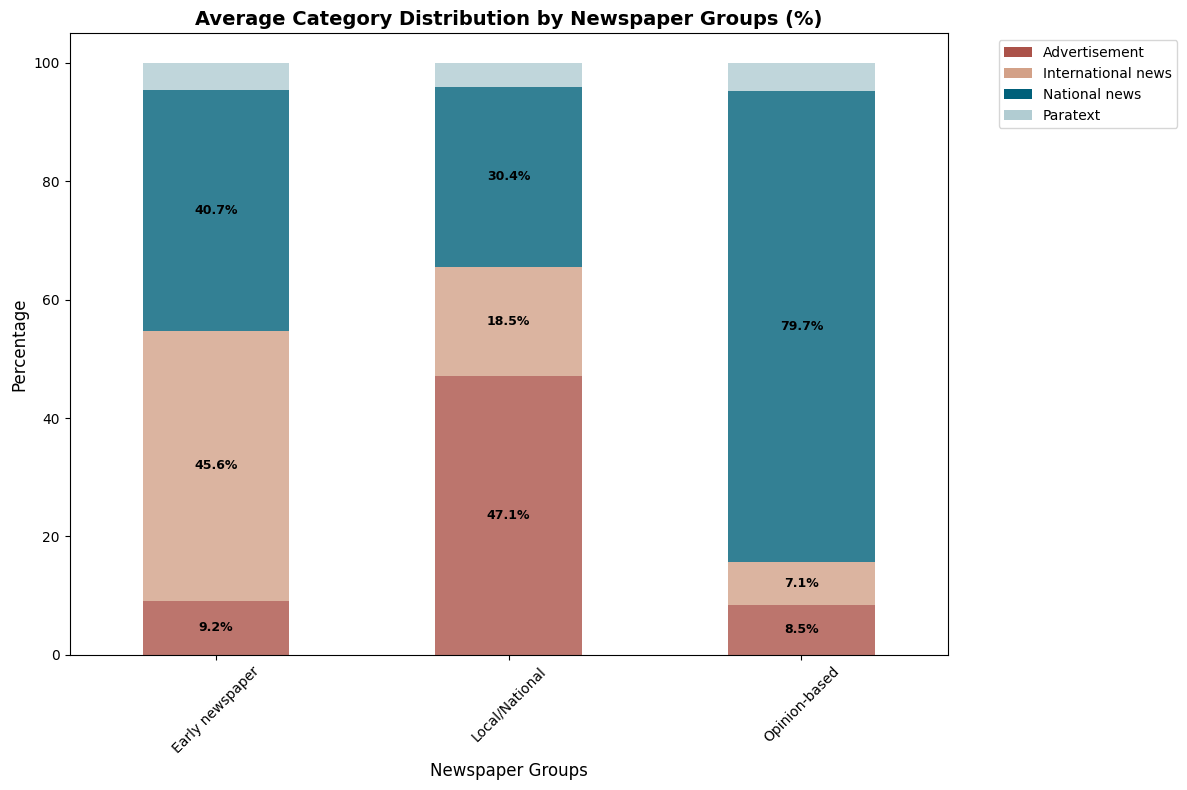

In [53]:
# Create a simple stacked bar chart showing category percentages for each newspaper group
fig, ax = plt.subplots(figsize=(12, 8))

# Create stacked bar chart
grouped_df.plot(kind='bar', stacked=True, ax=ax, 
                color= ['#AB5249', '#D3A188', '#00607A', '#B1CCD2'])

ax.set_title('Average Category Distribution by Newspaper Groups (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage', fontsize=12)
ax.set_xlabel('Newspaper Groups', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels on bars
for i, group in enumerate(grouped_df.index):
    cumulative = 0
    for category in grouped_df.columns:
        percentage = grouped_df.loc[group, category]
        if percentage > 5:  # Only show labels for percentages > 5%
            ax.text(i, cumulative + percentage/2, f'{percentage:.1f}%', 
                   ha='center', va='center', fontweight='bold', fontsize=9)
        cumulative += percentage


# increase transparency
for patch in ax.patches:
    patch.set_alpha(0.8)


plt.tight_layout()

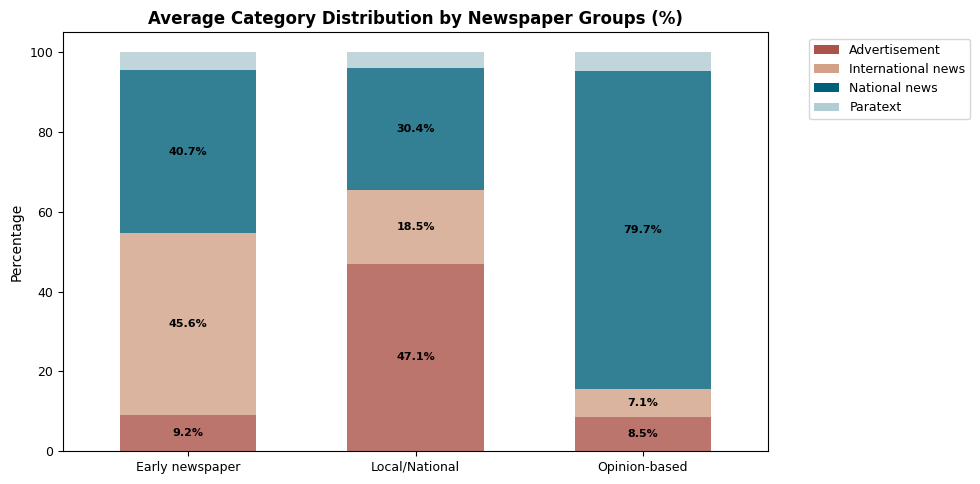

In [55]:
# Create a more compact stacked bar chart
fig, ax = plt.subplots(figsize=(10, 5))

# Create stacked bar chart with reduced bar width and spacing
bars = grouped_df.plot(kind='bar', stacked=True, ax=ax, 
                      color=['#AB5249', '#D3A188', '#00607A', '#B1CCD2'],
                      width=0.6)  # Reduce bar width for tighter spacing

ax.set_title('Average Category Distribution by Newspaper Groups (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage', fontsize=10)
ax.set_xlabel('')  # Remove x-axis label
ax.tick_params(axis='x', rotation=0, labelsize=9)  # Horizontal tick labels
ax.tick_params(axis='y', labelsize=9)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

# Add percentage labels on bars
for i, group in enumerate(grouped_df.index):
    cumulative = 0
    for category in grouped_df.columns:
        percentage = grouped_df.loc[group, category]
        if percentage > 5:  # Only show labels for percentages > 5%
            ax.text(i, cumulative + percentage/2, f'{percentage:.1f}%', 
                   ha='center', va='center', fontweight='bold', fontsize=8)
        cumulative += percentage

# Increase transparency
for patch in ax.patches:
    patch.set_alpha(0.8)

plt.tight_layout()
plt.show()

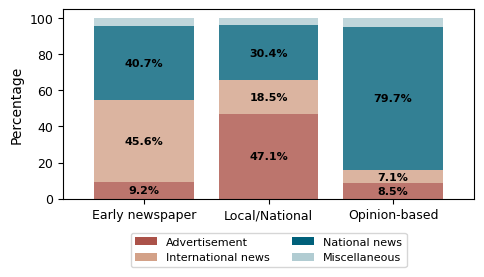

In [70]:
# Rename 'Paratext' to 'Miscellaneous' in grouped_df
grouped_df_renamed = grouped_df.rename(columns={'Paratext': 'Miscellaneous'})

# Create a more compact stacked bar chart with legend below
fig, ax = plt.subplots(figsize=(5, 3))

# Create stacked bar chart with reduced bar width and spacing
grouped_df_renamed.plot(kind='bar', stacked=True, ax=ax, 
                       color=['#AB5249', '#D3A188', '#00607A', '#B1CCD2'],
                       width=0.8)  # Increase bar width for closer spacing

#ax.set_title('Average Category Distribution by Newspaper Groups (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Percentage', fontsize=10)
ax.set_xlabel('')  # Remove x-axis label
ax.tick_params(axis='x', rotation=0, labelsize=9)  # Horizontal tick labels
ax.tick_params(axis='y', labelsize=9)

# Place legend below the plot in 3 columns
ax.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2, fontsize=8)

# Add percentage labels on bars
for i, group in enumerate(grouped_df_renamed.index):
    cumulative = 0
    for category in grouped_df_renamed.columns:
        percentage = grouped_df_renamed.loc[group, category]
        if percentage > 5:  # Only show labels for percentages > 5%
            ax.text(i, cumulative + percentage/2, f'{percentage:.1f}%', 
                   ha='center', va='center', fontweight='bold', fontsize=8)
        cumulative += percentage

# Increase transparency
for patch in ax.patches:
    patch.set_alpha(0.8)


#lt.savefig('newspaper_group_distribution.pdf', bbox_inches='tight')
    
plt.tight_layout()

plt.show()

